In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
import anndata
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

In [2]:
# load data 
filename = '/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/gene_to_loc_predict/data/data_loc_to_gene.pkl'
alldata = pickle.load(open(filename,'rb'))
locals().update(alldata)

In [3]:
alldata.keys()

dict_keys(['X_train', 'X_test', 'X_val', 'X_niche_train', 'X_niche_test', 'X_niche_val', 'y_train', 'y_test', 'y_val'])

In [4]:
X_gene_list = [X_train, X_val, X_test ]
X_niche_list = [X_niche_train, X_niche_val, X_niche_test ]

In [5]:
# to be deleted
def fit_and_report(name, X_list, model, param_grid=None, scale=False):
    """
    Train |model| (optionally grid-searching over param_grid) and
    print/return MSE for val+test.
    """
    X_train_0, X_val_0,X_test_0 = X_list
    steps = []
    if scale:          # scaling is rarely useful for tree-based models
        steps.append(("scaler", StandardScaler()))
    steps.append(("reg", model))
    pipe = Pipeline(steps)

    if param_grid is None:
        pipe.fit(X_train_0, y_train)
    else:
        cv = KFold(n_splits=5, shuffle=True, random_state=1)
        gs = GridSearchCV(
            pipe, param_grid, cv=cv, scoring="neg_mean_squared_error",
            n_jobs=-1, verbose=0
        )
        gs.fit(X_train_0, y_train)
        pipe = gs.best_estimator_
        print(f"[{name}] best params:", gs.best_params_)

    # validation performance
    y_val_pred = pipe.predict(X_val_0)
    val_mse = mean_squared_error(y_val, y_val_pred, multioutput="raw_values")
    print(f"[{name}] val MSE (x, y, z): {val_mse.round(4)}  |  mean={val_mse.mean():.4f}")

    # final retrain on train+val before testing
    pipe.fit(np.vstack([X_train_0, X_val_0]), np.vstack([y_train, y_val]))
    y_test_pred = pipe.predict(X_test_0)
    
    test_mse = mean_squared_error(y_test, y_test_pred, multioutput="raw_values")
    test_r2  = r2_score(y_test, y_test_pred, multioutput="raw_values")
    print(f"[{name}] TEST MSE (x,y,z): {test_mse.round(4)};  mean={test_mse.mean():.4f}")
    print(f"[{name}] TEST  R² (x,y,z): {test_r2.round(4)};  mean={test_r2.mean():.4f}\n")

    return name, pipe, test_mse, test_r2



In [6]:
results = []

# 4.1  Linear regression (baseline)
results.append(fit_and_report("Linear", X_gene_list, LinearRegression()))

# 4.2  Ridge (tune α)
ridge_grid = {"reg__alpha": np.logspace(-3, 3, 7)}
results.append(
    fit_and_report("Ridge", X_gene_list, Ridge(), param_grid=ridge_grid)
)

# 4.3  Random Forest
rf_grid = {
    "reg__n_estimators": [200, 500],
    "reg__max_depth": [None, 10, 30],
    "reg__min_samples_leaf": [1, 3, 10],
}
results.append(
    fit_and_report("RandomForest", X_gene_list, RandomForestRegressor(random_state=0), rf_grid, scale=False)
)
# 4.4  Gradient Boosting (sklearn)
gb_base = MultiOutputRegressor(
    GradientBoostingRegressor(random_state=0)
)

gb_grid = {
    # Note the extra 'estimator' hop inside the pipeline:
    "reg__estimator__n_estimators": [300, 600],
    "reg__estimator__learning_rate": [0.05, 0.1],
    "reg__estimator__max_depth": [2, 3],
}

results.append(
    fit_and_report("GradBoost", X_gene_list, gb_base, gb_grid, scale=False)
)



# 4.5  XGBoost (optional)
xgb_base = MultiOutputRegressor(
    XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=0,
    )
)

# Now drill into the "estimator" inside the MultiOutputRegressor
xgb_grid = {
    "reg__estimator__n_estimators": [400, 800],
    "reg__estimator__learning_rate": [0.05, 0.1],
    "reg__estimator__max_depth": [3, 5],
    "reg__estimator__subsample": [0.8, 1.0],
}

results.append(
    fit_and_report("XGBoost", X_gene_list, xgb_base, xgb_grid, scale=False)
)
results_gene = results.copy()

[Linear] val MSE (x, y, z): [0.0007 0.008  0.0043]  |  mean=0.0043
[Linear] TEST MSE (x,y,z): [0.0008 0.0092 0.0027];  mean=0.0042
[Linear] TEST  R² (x,y,z): [0.7276 0.3409 0.3495];  mean=0.4727



/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.65035e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.86356e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.28144e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned m

[Ridge] best params: {'reg__alpha': np.float64(1000.0)}
[Ridge] val MSE (x, y, z): [0.0007 0.0051 0.0021]  |  mean=0.0026
[Ridge] TEST MSE (x,y,z): [0.0008 0.0068 0.0023];  mean=0.0033
[Ridge] TEST  R² (x,y,z): [0.747  0.5148 0.4429];  mean=0.5682

[RandomForest] best params: {'reg__max_depth': None, 'reg__min_samples_leaf': 1, 'reg__n_estimators': 500}
[RandomForest] val MSE (x, y, z): [0.0009 0.0055 0.0021]  |  mean=0.0029
[RandomForest] TEST MSE (x,y,z): [0.001  0.0061 0.002 ];  mean=0.0031
[RandomForest] TEST  R² (x,y,z): [0.6667 0.5599 0.5005];  mean=0.5757

[GradBoost] best params: {'reg__estimator__learning_rate': 0.05, 'reg__estimator__max_depth': 3, 'reg__estimator__n_estimators': 600}
[GradBoost] val MSE (x, y, z): [0.0006 0.0064 0.0022]  |  mean=0.0031
[GradBoost] TEST MSE (x,y,z): [0.0006 0.0063 0.002 ];  mean=0.0030
[GradBoost] TEST  R² (x,y,z): [0.8054 0.547  0.5083];  mean=0.6203

[XGBoost] best params: {'reg__estimator__learning_rate': 0.05, 'reg__estimator__max_depth':

# results

In [7]:
print("\n=== Test-set leaderboard (mean MSE) ===")
for name, _, mse, r2 in sorted(results, key=lambda t: t[2].mean()):
    print(f"{name:<12}  r2={r2.mean():2f} mean MSE: {mse.mean():.5f}  (x={mse[0]:.5f}, y={mse[1]:.5f}, z={mse[2]:.5f})")



=== Test-set leaderboard (mean MSE) ===
GradBoost     r2=0.620251 mean MSE: 0.00297  (x=0.00059, y=0.00632, z=0.00201)
XGBoost       r2=0.620098 mean MSE: 0.00304  (x=0.00054, y=0.00657, z=0.00201)
RandomForest  r2=0.575691 mean MSE: 0.00306  (x=0.00101, y=0.00614, z=0.00204)
Ridge         r2=0.568243 mean MSE: 0.00327  (x=0.00077, y=0.00677, z=0.00227)
Linear        r2=0.472682 mean MSE: 0.00423  (x=0.00083, y=0.00920, z=0.00265)


In [8]:
best_name, best_model, best_mse, best_r2 = min(results, key=lambda t: t[2].mean())
print(f"🏆  Best model = {best_name}, mean R2 ={best_r2.mean():2f} mean MSE = {best_mse.mean():.5f}")

🏆  Best model = GradBoost, mean R2 =0.620251 mean MSE = 0.00297


In [9]:
best_r2

array([0.80543303, 0.54702936, 0.50829061])

# potentially add nicheformer results

In [ ]:
results_niche = []

# 4.1  Linear regression (baseline)
results_niche.append(fit_and_report("Linear", X_niche_list, LinearRegression()))

# 4.2  Ridge (tune α)
ridge_grid = {"reg__alpha": np.logspace(-3, 3, 7)}
results_niche.append(
    fit_and_report("Ridge", X_niche_list, Ridge(), param_grid=ridge_grid)
)

# 4.3  Random Forest
rf_grid = {
    "reg__n_estimators": [200, 500],
    "reg__max_depth": [None, 10, 30],
    "reg__min_samples_leaf": [1, 3, 10],
}
results_niche.append(
    fit_and_report("RandomForest", X_niche_list,RandomForestRegressor(random_state=0), rf_grid, scale=False)
)
# 4.4  Gradient Boosting (sklearn)
gb_base = MultiOutputRegressor(
    GradientBoostingRegressor(random_state=0)
)

gb_grid = {
    # Note the extra 'estimator' hop inside the pipeline:
    "reg__estimator__n_estimators": [300, 600],
    "reg__estimator__learning_rate": [0.05, 0.1],
    "reg__estimator__max_depth": [2, 3],
}

results_niche.append(
    fit_and_report("GradBoost", X_niche_list, gb_base, gb_grid, scale=False)
)



# 4.5  XGBoost (optional)
xgb_base = MultiOutputRegressor(
    XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=0,
    )
)

# Now drill into the "estimator" inside the MultiOutputRegressor
xgb_grid = {
    "reg__estimator__n_estimators": [400, 800],
    "reg__estimator__learning_rate": [0.05, 0.1],
    "reg__estimator__max_depth": [3, 5],
    "reg__estimator__subsample": [0.8, 1.0],
}

results_niche.append(
    fit_and_report("XGBoost", X_niche_list,xgb_base, xgb_grid, scale=False)
)


[Linear] val MSE (x, y, z): [0.0035 0.0152 0.0039]  |  mean=0.0075
[Linear] TEST MSE (x,y,z): [0.0031 0.0132 0.004 ];  mean=0.0068
[Linear] TEST  R² (x,y,z): [-0.0095  0.0565  0.0123];  mean=0.0198



/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.54757e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.57391e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.52845e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned m

[Ridge] best params: {'reg__alpha': np.float64(1000.0)}
[Ridge] val MSE (x, y, z): [0.0022 0.0084 0.0027]  |  mean=0.0044
[Ridge] TEST MSE (x,y,z): [0.0026 0.0106 0.0034];  mean=0.0056
[Ridge] TEST  R² (x,y,z): [0.1395 0.2373 0.1633];  mean=0.1800

[RandomForest] best params: {'reg__max_depth': None, 'reg__min_samples_leaf': 3, 'reg__n_estimators': 500}
[RandomForest] val MSE (x, y, z): [0.0025 0.0096 0.0029]  |  mean=0.0050
[RandomForest] TEST MSE (x,y,z): [0.0029 0.0129 0.0039];  mean=0.0066
[RandomForest] TEST  R² (x,y,z): [0.0355 0.0763 0.0359];  mean=0.0493

[GradBoost] best params: {'reg__estimator__learning_rate': 0.05, 'reg__estimator__max_depth': 3, 'reg__estimator__n_estimators': 600}
[GradBoost] val MSE (x, y, z): [0.0024 0.01   0.0031]  |  mean=0.0052
[GradBoost] TEST MSE (x,y,z): [0.0031 0.0119 0.0042];  mean=0.0064
[GradBoost] TEST  R² (x,y,z): [-0.0173  0.144  -0.0401];  mean=0.0289



In [16]:
print("\n=== Test-set leaderboard (mean MSE) ===")
for name, _, mse, r2 in sorted(results_niche, key=lambda t: t[2].mean()):
    print(f"{name:<12}  r2={r2.mean():2f} mean MSE: {mse.mean():.5f}  (x={mse[0]:.5f}, y={mse[1]:.5f}, z={mse[2]:.5f})")



=== Test-set leaderboard (mean MSE) ===
Ridge         r2=0.180034 mean MSE: 0.00556  (x=0.00262, y=0.01065, z=0.00341)
XGBoost       r2=0.069537 mean MSE: 0.00630  (x=0.00293, y=0.01203, z=0.00394)
GradBoost     r2=0.028878 mean MSE: 0.00643  (x=0.00310, y=0.01195, z=0.00424)
RandomForest  r2=0.049256 mean MSE: 0.00659  (x=0.00294, y=0.01289, z=0.00393)
Linear        r2=0.019785 mean MSE: 0.00676  (x=0.00307, y=0.01317, z=0.00403)


In [17]:
best_name, best_model, best_mse, best_r2 = min(results_niche, key=lambda t: t[2].mean())
print(f"🏆  Best model = {best_name}, mean R2 ={best_r2.mean():2f} mean MSE = {best_mse.mean():.5f}")

🏆  Best model = Ridge, mean R2 =0.180034 mean MSE = 0.00556


In [18]:
best_r2

array([0.13954522, 0.23725647, 0.16329939])

# summary plot!

In [20]:
results_gene = results.copy()

<Figure size 800x500 with 0 Axes>

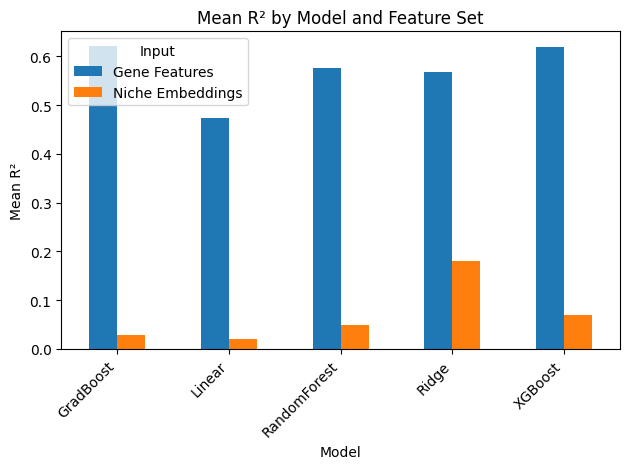

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

def summarize_r2(results_list, input_name):
    records = []
    for name, _, mse, r2 in results_list:
        records.append({
            "Input": input_name,
            "Model": name,
            "Mean R²": r2.mean()
        })
    return pd.DataFrame.from_records(records)

# Summarize both result sets
df_gene_r2  = summarize_r2(results_gene,  "Gene Features")
df_niche_r2 = summarize_r2(results_niche, "Niche Embeddings")

df_r2 = pd.concat([df_gene_r2, df_niche_r2], ignore_index=True)

# Pivot for plotting
df_plot_r2 = df_r2.pivot(index="Model", columns="Input", values="Mean R²")

# Plot grouped bar chart
plt.figure(figsize=(8, 5))
df_plot_r2.plot(kind='bar')
plt.title("Mean R² by Model and Feature Set")
plt.xlabel("Model")
plt.ylabel("Mean R²")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# visualize the predicted results

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3-D projection
import numpy as np

def plot_xyz_predictions(model, X, y_true, n_show=None, title="XYZ prediction"):
    """
    3-D scatter of ground-truth coordinates and model predictions.
    Optionally draws error vectors (ŷ − y) for a small random subset.
    """
    y_pred = model.predict(X)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    
    # true locations
    ax.scatter(*y_true.T, c="k", s=8, alpha=0.5, label="true")
    # predictions
    ax.scatter(*y_pred.T, c="tab:orange", s=8, alpha=0.5, label="pred")
    
    # draw arrows for a subset so the plot stays readable
    if n_show is None:
        n_show = min(75, len(y_true))
    idx = np.random.choice(len(y_true), n_show, replace=False)
    for i in idx:
        ax.plot(
            [y_true[i, 0], y_pred[i, 0]],
            [y_true[i, 1], y_pred[i, 1]],
            [y_true[i, 2], y_pred[i, 2]],
            lw=0.6, c="gray", alpha=0.4
        )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()
    ax.set_title(title + f"\nmean MSE = {((y_true - y_pred)**2).mean():.4f}")
    plt.tight_layout()
    plt.show()


In [ ]:
plot_xyz_predictions(best_model, X_test, y_test, n_show=10,
                     title=f"{best_name} – test set")


In [ ]:
almeshes = utils.load_sym_mesh()

def plot_2d_projections(model, X, y_true):
    y_pred = model.predict(X)
    diffs   = np.sqrt(((y_true - y_pred)**2).sum(1))   # Euclidean error per cell
    cmap    = plt.cm.viridis
    cmap = 'bwr'
    panels = [("AP","DV",(0,1)), ("AP","ML",(0,2)), ("ML","DV",(2,1))]

    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    for ax, (labx, laby, (i,j)) in zip(axs, panels):
        sc = ax.scatter(y_true[:,i], y_true[:,j],
                        c=diffs, s=3, alpha = 1,cmap=cmap, vmin=diffs.min(), vmax=diffs.max()*0.5)
        ax.set_xlabel(labx); ax.set_ylabel(laby)
        ax.set_aspect("equal")
        ax.set_title(f"{laby} vs. {labx}")
#     plotting.plot_mesh(ax=axs[0], allmeshes=almeshes, direction='s')
#     plotting.plot_mesh(ax=axs[2], allmeshes=almeshes, direction='c')
    fig.colorbar(sc, ax=ax, label="prediction error (µm)")
    fig.suptitle("Per-cell spatial error heat-map", y=1.02)
    plt.tight_layout()

    
plot_2d_projections(best_model, X_test, y_test)


In [ ]:


def plot_2d_projections_with_arrows(
    model, X, y_true, n_show=10, random_state=None, cmap=plt.cm.viridis
):
    """
    Plot 3 panels (XY, XZ, YZ) for a random subset of n_show cells,
    color‐coding by Euclidean error, and drawing arrows from true→predicted.
    """
    # predict
    y_pred = model.predict(X)
    # compute per‐cell Euclidean error
    errs = np.linalg.norm(y_true - y_pred, axis=1)
    
    # choose subset of indices
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(y_true), size=min(n_show, len(y_true)), replace=False)
    
    panels = [("AP","DV",(0,1)), ("AP","ML",(0,2)), ("ML","DV",(2,1))]
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    
    for ax, (labx, laby, (i,j)) in zip(axs, panels):
        # scatter only the chosen points
        sc = ax.scatter(
            y_true[idx, i], y_true[idx, j],
            c=errs[idx], s=10, cmap=cmap,
            vmin=errs.min(), vmax=errs.max(), edgecolor="k"
        )
        # draw arrows for each selected cell
        for k in idx:
            dx = y_pred[k, i] - y_true[k, i]
            dy = y_pred[k, j] - y_true[k, j]
            ax.arrow(
                y_true[k, i], y_true[k, j],
                dx, dy,
                head_width=0.02 * max(errs), head_length=0.02 * max(errs),
                fc="gray", ec="gray", alpha=0.7, length_includes_head=True
            )
        
        ax.set_xlabel(labx)
        ax.set_ylabel(laby)
        ax.set_aspect("equal")
        ax.set_title(f"{laby} vs {labx}")
    plotting.plot_mesh(ax=axs[0], allmeshes=almeshes, direction='s')
    plotting.plot_mesh(ax=axs[2], allmeshes=almeshes, direction='c')
    # shared colorbar
    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Euclidean error (µm)")
    fig.suptitle(f"Spatial error on {len(idx)} selected cells", y=1.02)
    plt.tight_layout()
    plt.show()


# Usage: select 10 random test cells and plot
plot_2d_projections_with_arrows(best_model, X_test, y_test, n_show=40, random_state=42)

In [ ]:
X_test.shape

In [ ]:
from scipy.spatial.distance import cdist

def plot_error_hist(model, X, y_true, bins=30):
    y_pred = model.predict(X)
    errs   = np.linalg.norm(y_true - y_pred, axis=1)   # Euclidean
    plt.figure(figsize=(4,3))
    plt.hist(errs, bins=bins, alpha=0.8)
    plt.xlabel("Euclidean error (µm)")
    plt.ylabel("# cells")
    plt.title(f"Median error = {np.median(errs):.2f} µm")
    plt.tight_layout()
    plt.show()
plot_error_hist(best_model, X_test, y_test)

# MAE

In [ ]:
from sklearn.metrics import mean_absolute_error

y_pred = best_model.predict(X_test)

# y_true, y_pred are shape (n_samples, 3)
mae_per_axis = mean_absolute_error(y_test, y_pred)#, multioutput="raw_values")
mae_mean     = mean_absolute_error(y_test, y_pred)#, multioutput="uniform_average")

print("MAE (AP, DV, ML):", mae_per_axis)
print("Average MAE:",    mae_mean)

In [ ]:
np.ptp(y_test, 0)

# pseudoclusters 

In [ ]:
me = utils.load_mesh()
plt.scatter(df['ML'],df['DV'], c = df['pseudocluster'], cmap = 'PiYG', s=3)
plotting.plot_mesh(plt.gca(), allmeshes = me)

In [ ]:
plt.scatter(y_train[:,2],y_train[:,1], c = pc_train, cmap = 'PiYG');
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')

In [ ]:

model = LinearRegression().fit(pc_train.reshape(-1,1), y_train)
y_pred = model.predict(pc_test.reshape(-1,1))
print("MSE (mean):", mean_squared_error(y_test, y_pred))#, multioutput="raw_values"))
print("R² (mean):", r2_score(y_test, y_pred))#, multioutput="raw_values"))


model = Ridge().fit(pc_train.reshape(-1,1), y_train)
y_pred = model.predict(pc_test.reshape(-1,1))
print("MSE (mean):", mean_squared_error(y_test, y_pred))#, multioutput="raw_values"))
print("R² (mean):", r2_score(y_test, y_pred))#, multioutput="raw_values"))